# Email Spam Detection with Machine Learning
## NLP Binary Classifier: Spam vs. Ham

**Objective:** Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.

**Tech Stack:** Python, pandas, scikit-learn (TF-IDF, Naive Bayes, SVM), NLTK, matplotlib, seaborn

**Dataset:** [SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) (Kaggle)

---

In [1]:

import pandas as pd
import numpy as np

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("done !")

done !


In [2]:

import os

df = None
loaded_file = None

possible_files = [
    ('spam.csv', 'csv'),
    ('SMSSpamCollection', 'tsv'),
    ('sms.tsv', 'tsv'),
    ('spam.tsv', 'tsv'),
    ('spam.csv', 'csv'),
]

for fname, ftype in possible_files:
    if os.path.exists(fname):
        if ftype == 'csv':
            try:
                df = pd.read_csv(fname, encoding='latin-1')
            except:
                try:
                    df = pd.read_csv(fname, encoding='utf-8')
                except:
                    df = pd.read_csv(fname, encoding='latin-1', sep='\t')
        else:
            df = pd.read_csv(fname, sep='\t', header=None, names=['label', 'message'])
        loaded_file = fname
        print(f" Loaded: {fname}")
        break

if df is None:
    files = [f for f in os.listdir('.') if f.endswith(('.csv', '.tsv', '.txt'))]
    print(" Could not find the dataset.")
    print(f"   Files found: {files}")
    print("   Please download from Kaggle and place the file here.")
else:
    print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumns: {df.columns.tolist()}")
    print("\nFirst 5 rows:")
    display(df.head())

 Loaded: spam.csv

Dataset shape: 5572 rows × 5 columns

Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:

print("=== ALL COLUMNS ===")
print(df.columns.tolist())

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

col_map = {}
for col in df.columns:
    lower = col.lower().strip()
    if lower in ['v1', 'label', 'class', 'category']:
        col_map[col] = 'label'
    elif lower in ['v2', 'message', 'text', 'sms', 'email', 'content']:
        col_map[col] = 'message'

df = df.rename(columns=col_map)

if 'label' in df.columns and 'message' in df.columns:
    df = df[['label', 'message']].copy()
    print(" Standardized to 'label' and 'message' columns")
else:
    print(" Could not find expected columns. Available:")
    print(df.columns.tolist())

print(f"\nData types:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

=== ALL COLUMNS ===
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
 Standardized to 'label' and 'message' columns

Data types:
label      object
message    object
dtype: object

Null values:
label      0
message    0
dtype: int64

Duplicate rows: 403


=== CLASS DISTRIBUTION ===
       Count  Percentage
label                   
ham     4825       86.59
spam     747       13.41


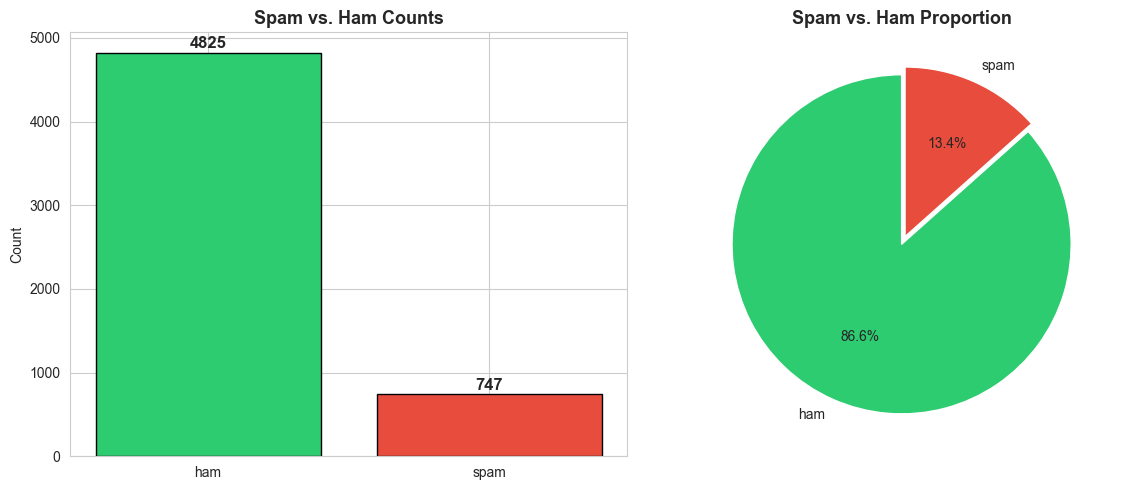


 The dataset is imbalanced ham (legitimate) messages outnumber spam.
   This is realistic: in real life, most emails are legitimate.


In [4]:

df['label'] = df['label'].astype(str).str.strip().str.lower()

label_map = {'ham': 'ham', 'spam': 'spam', '0': 'ham', '1': 'spam'}
df['label'] = df['label'].map(lambda x: label_map.get(x, x))

counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
distribution = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages.round(2)
})
print(distribution)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']  
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Spam vs. Ham Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
          colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Spam vs. Ham Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n The dataset is imbalanced ham (legitimate) messages outnumber spam.")
print(f"   This is realistic: in real life, most emails are legitimate.")

In [5]:

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\d+', '', text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

df['message_clean'] = df['message'].apply(preprocess_text)

print("\n=== BEFORE vs AFTER PREPROCESSING ===\n")
for i in range(3):
    print(f"Original:  {df['message'].iloc[i]}")
    print(f"Cleaned:   {df['message_clean'].iloc[i]}")
    print(f"Label:     {df['label'].iloc[i]}")



=== BEFORE vs AFTER PREPROCESSING ===

Original:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:   jurong point crazi avail bugi great world buffet cine got amor wat
Label:     ham
Original:  Ok lar... Joking wif u oni...
Cleaned:   lar joke wif oni
Label:     ham
Original:  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned:   free entri wkli comp win cup final tkt may text receiv entri questionstd txt ratetc appli over
Label:     spam


---
## Step 5: Feature Extraction with TF-IDF

### What is TF-IDF?

**TF-IDF** stands for **Term Frequency — Inverse Document Frequency**. It is a numerical statistic that reflects how important a word is to a document in a collection (corpus).

**TF (Term Frequency):** How often a word appears in a single document.
```
TF = (Number of times word appears in document) / (Total words in document)
```

**IDF (Inverse Document Frequency):** How rare a word is across all documents.
```
IDF = log(Total documents / Number of documents containing the word)
```

**TF-IDF Score = TF × IDF**

**Why TF-IDF for spam detection?**
- Words like "free", "win", "prize" appear frequently in spam but rarely in ham → high TF-IDF for spam
- Common words like "the", "and" appear everywhere → low IDF, low TF-IDF → automatically downweighted
- TF-IDF converts text into a numeric matrix that ML algorithms can process

**In scikit-learn:** `TfidfVectorizer` combines tokenization, vocabulary building, and TF-IDF transformation in one step.

In [6]:


tfidf = TfidfVectorizer(
    max_features=5000,      
    min_df=2,                 
    max_df=0.95,              
    ngram_range=(1, 2)        
)

X = tfidf.fit_transform(df['message_clean'])

y = df['label'].map({'ham': 0, 'spam': 1})

print(f"TF-IDF matrix shape: {X.shape}")
print(f"  → {X.shape[0]} messages")
print(f"  → {X.shape[1]} unique features (words/bigrams)")
print(f"\nTarget distribution:")
print(f"  Ham (0): {(y == 0).sum()} messages")
print(f"  Spam (1): {(y == 1).sum()} messages")

feature_names = tfidf.get_feature_names_out()
print(f"\nSample features: {feature_names[:20].tolist()}")

TF-IDF matrix shape: (5572, 5000)
  → 5572 messages
  → 5000 unique features (words/bigrams)

Target distribution:
  Ham (0): 4825 messages
  Spam (1): 747 messages

Sample features: ['aah', 'aathilov', 'aathilov lot', 'aathiwher', 'aathiwher dear', 'abi', 'abil', 'abiola', 'abj', 'abl', 'abl come', 'abl deliv', 'abl get', 'abl pay', 'abt', 'abt alreadi', 'abt tht', 'abta', 'abta complimentari', 'aburo']


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Features:     {X_train.shape[1]} TF-IDF features")

print(f"\nTraining set — Ham: {(y_train == 0).sum()}, Spam: {(y_train == 1).sum()}")
print(f"Test set     — Ham: {(y_test == 0).sum()}, Spam: {(y_test == 1).sum()}")

Training set: 4457 samples (80%)
Test set:     1115 samples (20%)
Features:     5000 TF-IDF features

Training set — Ham: 3859, Spam: 598
Test set     — Ham: 966, Spam: 149


In [8]:

models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(kernel='linear', random_state=42)
}

results = {}

print("=== TRAINING MODELS ===\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }
    
    print(f" {name}")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print()


=== TRAINING MODELS ===

 Multinomial Naive Bayes
   Accuracy:  0.9704
   Precision: 0.9833
   Recall:    0.7919
   F1-Score:  0.8773

 Logistic Regression
   Accuracy:  0.9587
   Precision: 0.9640
   Recall:    0.7181
   F1-Score:  0.8231

 Support Vector Machine
   Accuracy:  0.9839
   Precision: 0.9781
   Recall:    0.8993
   F1-Score:  0.9371



=== MODEL COMPARISON ===
                  Model  Accuracy  Precision  Recall  F1-Score
 Support Vector Machine    0.9839     0.9781  0.8993    0.9371
Multinomial Naive Bayes    0.9704     0.9833  0.7919    0.8773
    Logistic Regression    0.9587     0.9640  0.7181    0.8231


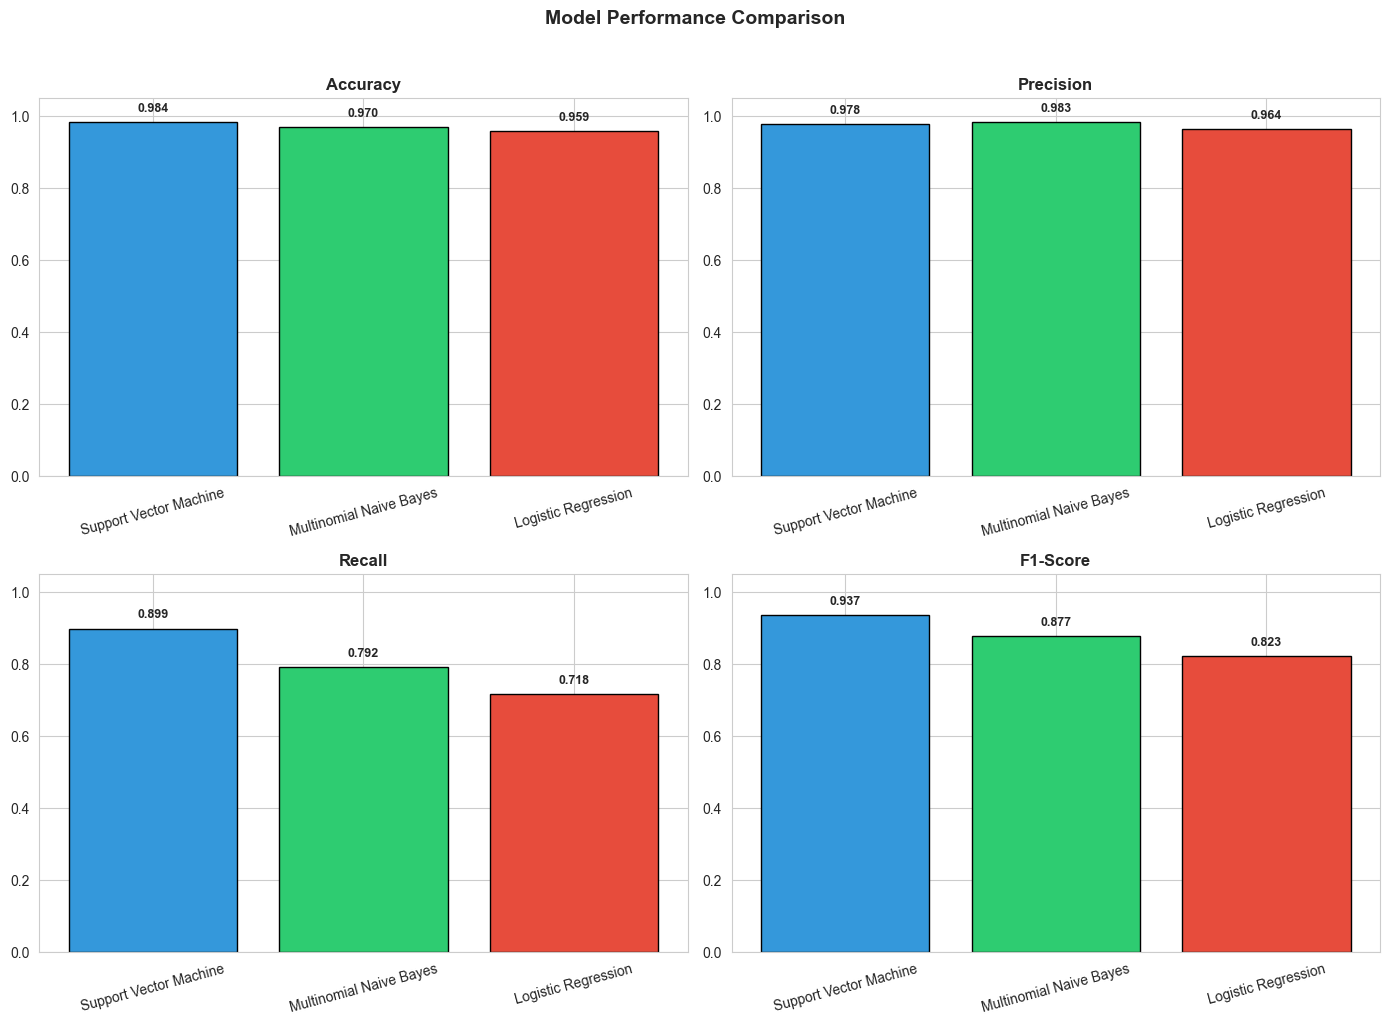


 BEST MODEL (by F1-Score): Support Vector Machine


In [9]:

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()]
})

comparison = comparison.sort_values('F1-Score', ascending=False)

print("=== MODEL COMPARISON ===")
print(comparison.round(4).to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, metric in enumerate(metrics):
    bars = axes[idx].bar(comparison['Model'], comparison[metric], color=colors, edgecolor='black')
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1.05)
    axes[idx].tick_params(axis='x', rotation=15)
    
    for bar, val in zip(bars, comparison[metric]):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                      f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_model_name = comparison.iloc[0]['Model']
print(f"\n BEST MODEL (by F1-Score): {best_model_name}")

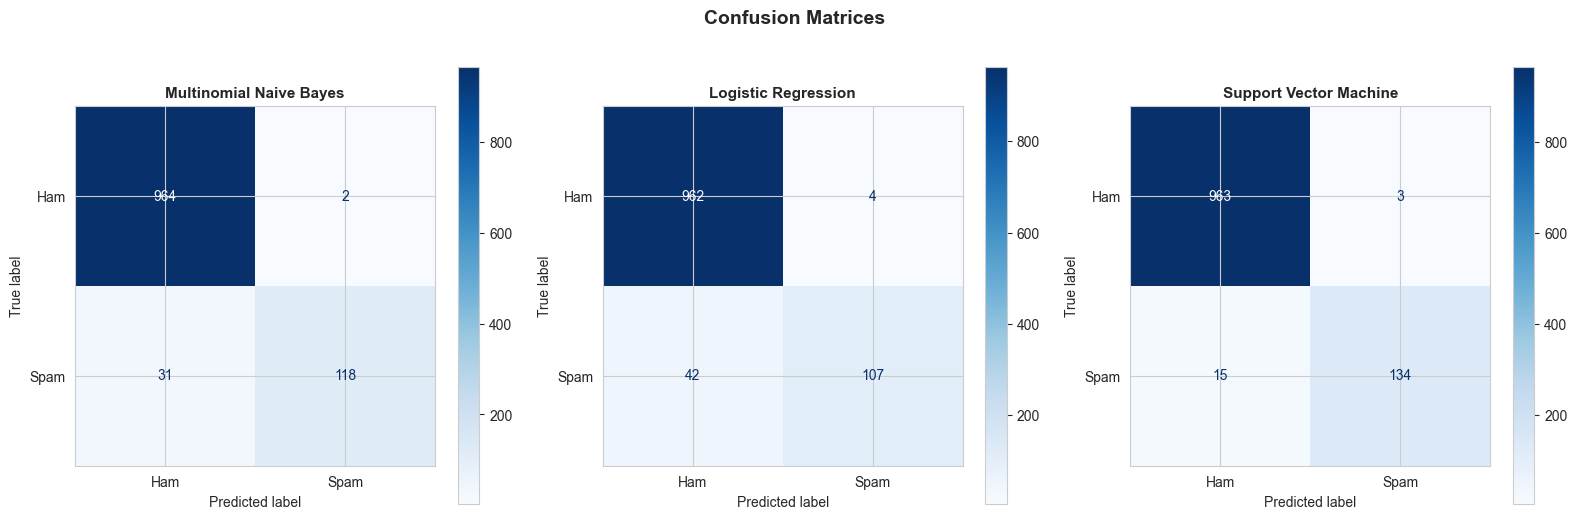

In [10]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Ham', 'Spam']
    )
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=True)
    axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [11]:

print("=== DETAILED CLASSIFICATION REPORTS ===\n")

for name, result in results.items():
    print(f"{'='*55}")
    print(f"{name.upper()}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, result['predictions'],
        target_names=['Ham', 'Spam'],
        digits=4
    ))
    print()

=== DETAILED CLASSIFICATION REPORTS ===

MULTINOMIAL NAIVE BAYES
              precision    recall  f1-score   support

         Ham     0.9688    0.9979    0.9832       966
        Spam     0.9833    0.7919    0.8773       149

    accuracy                         0.9704      1115
   macro avg     0.9761    0.8949    0.9302      1115
weighted avg     0.9708    0.9704    0.9690      1115


LOGISTIC REGRESSION
              precision    recall  f1-score   support

         Ham     0.9582    0.9959    0.9766       966
        Spam     0.9640    0.7181    0.8231       149

    accuracy                         0.9587      1115
   macro avg     0.9611    0.8570    0.8999      1115
weighted avg     0.9589    0.9587    0.9561      1115


SUPPORT VECTOR MACHINE
              precision    recall  f1-score   support

         Ham     0.9847    0.9969    0.9907       966
        Spam     0.9781    0.8993    0.9371       149

    accuracy                         0.9839      1115
   macro avg     0

---
## Step 9: Why is Recall Particularly Important for Spam Detection?

### The Answer

In spam detection, **Recall (Sensitivity)** measures: "Of all actual spam messages, how many did we correctly identify?"

**Formula:** `Recall = True Positives / (True Positives + False Negatives)`

### Why Recall Matters Most

| Scenario | False Positive (FP) | False Negative (FN) | Impact |
|----------|---------------------|---------------------|--------|
| FP: Ham → Spam | Legitimate email sent to spam folder | — | User misses an important email |
| FN: Spam → Ham | — | Spam lands in inbox | User sees phishing/scam, potential fraud/loss |

**The cost of a False Negative (missing spam) is much higher than a False Positive (filtering ham):**

1. **Financial Risk:** A missed phishing email could lead to stolen credentials, bank fraud, or identity theft.
2. **Security Risk:** Spam often contains malware links. Letting it through compromises the entire system.
3. **User Trust:** Users forgive occasional legitimate emails in spam (they check spam folders). They do NOT forgive spam in their inbox.
4. **Legal/Compliance:** In enterprise settings, missing spam with malicious content can violate security policies.

**Therefore:** We prioritize models with high **Recall** for spam, even if it means slightly lower Precision. A spam filter that catches 99% of spam (high recall) with some false positives is far better than one that lets spam through (low recall) to avoid false alarms.

**In practice:** Many spam filters use a threshold that favors recall. The F1-score balances both, but recall is the primary safety metric.

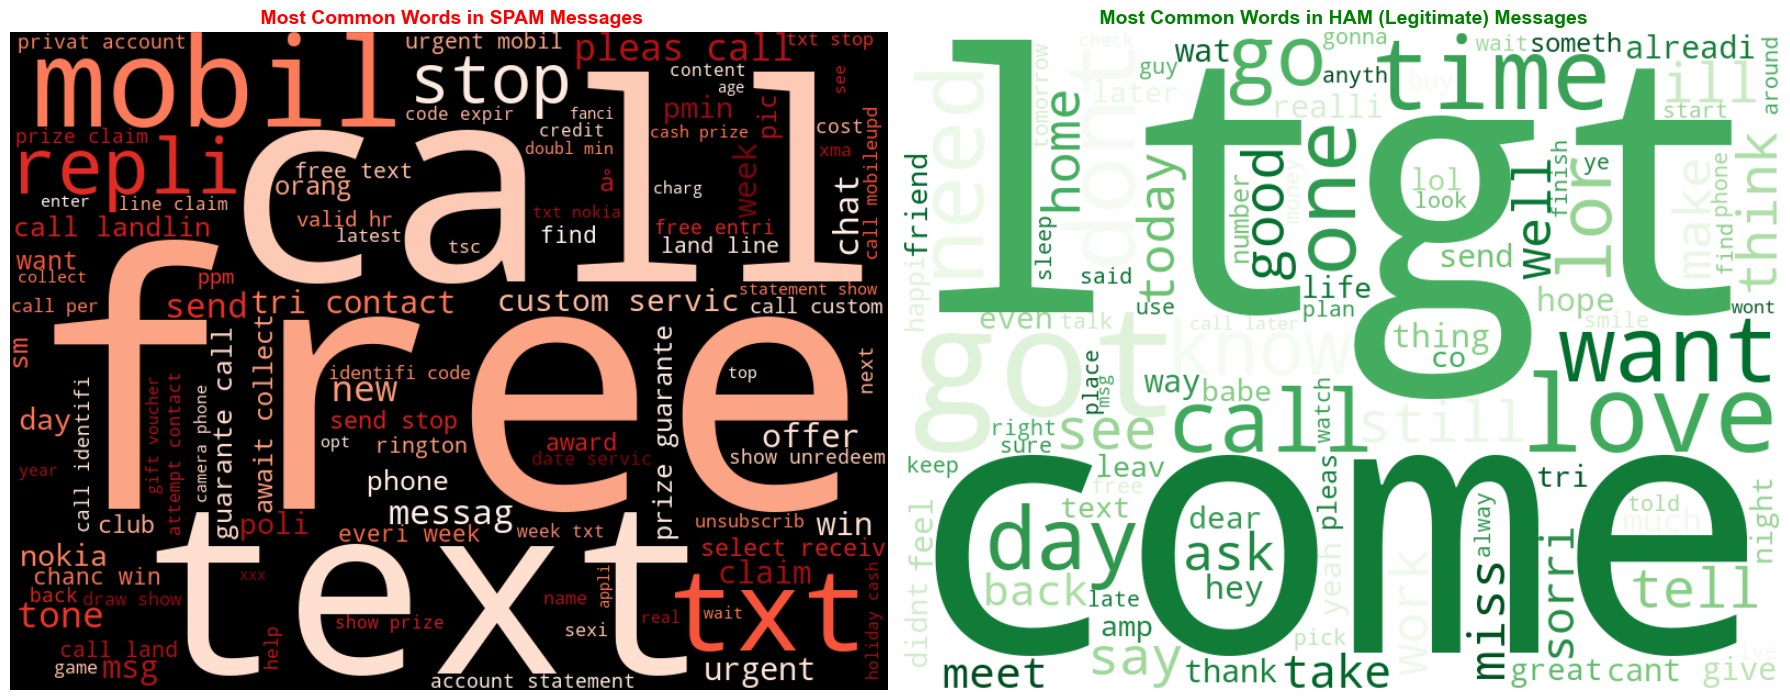

 Spam WordCloud shows words like 'free', 'call', 'txt', 'win', 'prize', 'claim' typical spam triggers.
   Ham WordCloud shows conversational words 'get', 'time', 'home', 'love', 'good' normal communication.


In [13]:

spam_text = ' '.join(df[df['label'] == 'spam']['message_clean'].tolist())
ham_text = ' '.join(df[df['label'] == 'ham']['message_clean'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

spam_wc = WordCloud(
    width=800, height=600,
    background_color='black',
    colormap='Reds',
    max_words=100,
    contour_width=1
).generate(spam_text)

axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].set_title(' Most Common Words in SPAM Messages', fontsize=14, fontweight='bold', color='red')
axes[0].axis('off')

ham_wc = WordCloud(
    width=800, height=600,
    background_color='white',
    colormap='Greens',
    max_words=100,
    contour_width=1
).generate(ham_text)

axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].set_title(' Most Common Words in HAM (Legitimate) Messages', fontsize=14, fontweight='bold', color='green')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(" Spam WordCloud shows words like 'free', 'call', 'txt', 'win', 'prize', 'claim' typical spam triggers.")
print("   Ham WordCloud shows conversational words 'get', 'time', 'home', 'love', 'good' normal communication.")

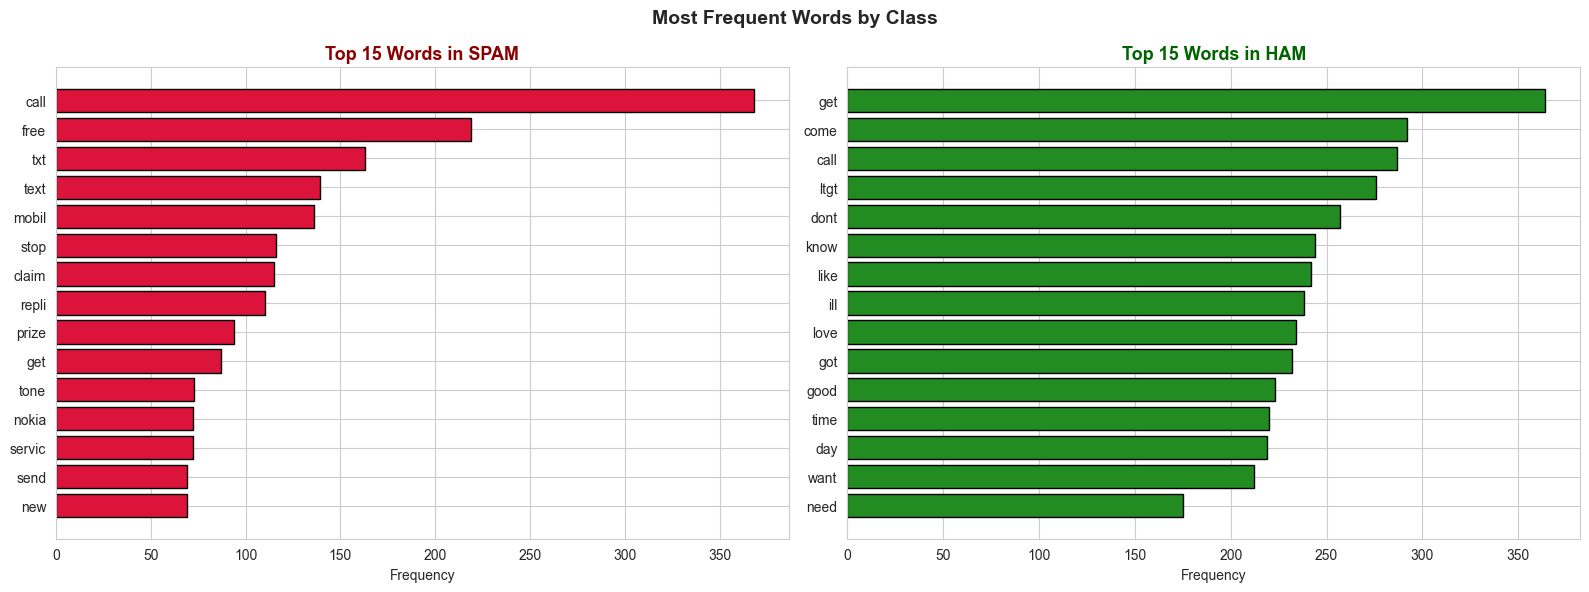

 These are the RAW frequencies (before TF-IDF weighting).
   TF-IDF would further downweight common words and upweight discriminative ones.


In [14]:

from collections import Counter

spam_words = Counter(spam_text.split())
ham_words = Counter(ham_text.split())

top_spam = spam_words.most_common(15)
top_ham = ham_words.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

spam_df = pd.DataFrame(top_spam, columns=['Word', 'Count'])
axes[0].barh(spam_df['Word'][::-1], spam_df['Count'][::-1], color='crimson', edgecolor='black')
axes[0].set_title('Top 15 Words in SPAM', fontsize=13, fontweight='bold', color='darkred')
axes[0].set_xlabel('Frequency')

ham_df = pd.DataFrame(top_ham, columns=['Word', 'Count'])
axes[1].barh(ham_df['Word'][::-1], ham_df['Count'][::-1], color='forestgreen', edgecolor='black')
axes[1].set_title('Top 15 Words in HAM', fontsize=13, fontweight='bold', color='darkgreen')
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" These are the RAW frequencies (before TF-IDF weighting).")
print("   TF-IDF would further downweight common words and upweight discriminative ones.")

In [18]:

best_model = results[best_model_name]['model']

test_messages = [
    "Hey, are we still meeting for lunch tomorrow at noon?",
    "Congratulations! You've won a $1000 gift card. Call now to claim your prize!",
    "Can you pick up some milk on your way home?",
    "URGENT: Your account has been compromised. Click this link immediately to secure it.",
    "Thanks for the birthday wishes! Really appreciate it."
]

print(f"=== SPAM DETECTION DEMO ({best_model_name}) ===\n")

for msg in test_messages:
    
    clean = preprocess_text(msg)
    
    vec = tfidf.transform([clean])
    
    pred = best_model.predict(vec)[0]
    prob = best_model.predict_proba(vec)[0] if hasattr(best_model, 'predict_proba') else None
    
    label = 'SPAM' if pred == 1 else 'HAM'
    
    print(f"Message: {msg}")
    print(f"   Prediction: {label}")
    if prob is not None:
        print(f"   Confidence: {max(prob)*100:.1f}%")
    print()

=== SPAM DETECTION DEMO (Support Vector Machine) ===

Message: Hey, are we still meeting for lunch tomorrow at noon?
   Prediction: HAM

Message: Congratulations! You've won a $1000 gift card. Call now to claim your prize!
   Prediction: SPAM

Message: Can you pick up some milk on your way home?
   Prediction: HAM

Message: URGENT: Your account has been compromised. Click this link immediately to secure it.
   Prediction: SPAM

Message: Thanks for the birthday wishes! Really appreciate it.
   Prediction: HAM

